In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv('../raw/chemical_process_timeseries.csv')
print(f"DATASET SHAPE: {df.shape}")
print(f"FIRST 5 ROWS:\n{df.head(5)}")


DATASET SHAPE: (777600, 21)
FIRST 5 ROWS:
             timestamp operating_regime reactor_id  ambient_temp_effect  \
0  2024-01-01 00:00:00                A       A_R1             0.000000   
1  2024-01-01 00:01:00                A       A_R1             0.000485   
2  2024-01-01 00:02:00                A       A_R1             0.000970   
3  2024-01-01 00:03:00                A       A_R1             0.001454   
4  2024-01-01 00:04:00                A       A_R1             0.001939   

   reactor_temp  reactor_pressure  feed_flow_rate  coolant_flow_rate  \
0    181.135558         15.791013      101.108882          79.154645   
1    182.249820         15.706975       98.932369                NaN   
2    183.129737         15.593397       99.792219          80.593736   
3    183.020987         15.527333       99.854222          80.190444   
4    183.077096               NaN       99.302349          78.571707   

   agitator_speed_rpm  reaction_rate  ...  selectivity  yield_pct  \
0    

In [36]:
print('DATASET OVERVIEW:')
print("=" * 50)
print(df.columns)
print("=" * 50)
print(df.isna().mean().sort_values(ascending=False))
print("=" * 50)
print(df["fault_type"].value_counts())
print("=" * 50)
print(df["operating_regime"].value_counts())
print("=" * 50)
print(df["reactor_id"].nunique())

DATASET OVERVIEW:
Index(['timestamp', 'operating_regime', 'reactor_id', 'ambient_temp_effect',
       'reactor_temp', 'reactor_pressure', 'feed_flow_rate',
       'coolant_flow_rate', 'agitator_speed_rpm', 'reaction_rate',
       'conversion_rate', 'selectivity', 'yield_pct', 'vibration_rms',
       'motor_current', 'power_consumption_kw', 'temp_setpoint',
       'pressure_setpoint', 'fault_type', 'efficiency_loss_pct',
       'time_to_fault_min'],
      dtype='object')
time_to_fault_min       0.966195
selectivity             0.060711
reactor_pressure        0.060626
reactor_temp            0.060397
efficiency_loss_pct     0.060338
reaction_rate           0.060224
pressure_setpoint       0.060208
agitator_speed_rpm      0.060153
feed_flow_rate          0.060134
coolant_flow_rate       0.059986
motor_current           0.059950
ambient_temp_effect     0.059878
yield_pct               0.059830
temp_setpoint           0.059828
power_consumption_kw    0.059792
vibration_rms           0.0597

In [37]:
print(f"REACTOR ID COUNTS:\n{df['reactor_id'].value_counts()}")
print("=" * 50)
print(f"OPERATION REGIME COUNTS:\n{df['operating_regime'].value_counts()}")
print("=" * 50)
print(f"FAULT COUNTS:\n{df['fault_type'].value_counts()}")
print("=" * 50)
print(f"MISSING VALUES (as %):\n{df.isna().sum().sort_values(ascending=False)}")

REACTOR ID COUNTS:
reactor_id
A_R1    129600
A_R2    129600
A_R3    129600
B_R1    129600
B_R2    129600
B_R3    129600
Name: count, dtype: int64
OPERATION REGIME COUNTS:
operating_regime
A    388800
B    388800
Name: count, dtype: int64
FAULT COUNTS:
fault_type
0    749699
1      9143
4      7442
2      6842
3      4474
Name: count, dtype: int64
MISSING VALUES (as %):
time_to_fault_min       751313
selectivity              47209
reactor_pressure         47143
reactor_temp             46965
efficiency_loss_pct      46919
reaction_rate            46830
pressure_setpoint        46818
agitator_speed_rpm       46775
feed_flow_rate           46760
coolant_flow_rate        46645
motor_current            46617
ambient_temp_effect      46561
yield_pct                46524
temp_setpoint            46522
power_consumption_kw     46494
vibration_rms            46459
conversion_rate          46416
operating_regime             0
reactor_id                   0
timestamp                    0
fault_ty

In [38]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["reactor_id", "timestamp"])
#creating binary value for failure target
df["failure_risk"] = (df["fault_type"] != 0 ).astype(int)

In [39]:
#handling missing data
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = (
    df.groupby("reactor_id")[numeric_columns]
    .transform(lambda x: x.interpolate().ffill().bfill())   
)
#check
print(f"MISSING VALUES AFTER IMPUTATION (as %):\n{df.isna().mean().sort_values(ascending=False)}")

MISSING VALUES AFTER IMPUTATION (as %):
timestamp               0.0
operating_regime        0.0
reactor_id              0.0
ambient_temp_effect     0.0
reactor_temp            0.0
reactor_pressure        0.0
feed_flow_rate          0.0
coolant_flow_rate       0.0
agitator_speed_rpm      0.0
reaction_rate           0.0
conversion_rate         0.0
selectivity             0.0
yield_pct               0.0
vibration_rms           0.0
motor_current           0.0
power_consumption_kw    0.0
temp_setpoint           0.0
pressure_setpoint       0.0
fault_type              0.0
efficiency_loss_pct     0.0
time_to_fault_min       0.0
failure_risk            0.0
dtype: float64


In [40]:
#save cleaned data
df.to_csv('../processed/cleaned_chemical_process_timeseries.csv', index=False)  

In [41]:
#how many failure happened in each operating regime
failure_count = df.groupby('operating_regime')['failure_risk'].sum()
print(failure_count)

operating_regime
A    13994
B    13907
Name: failure_risk, dtype: int64


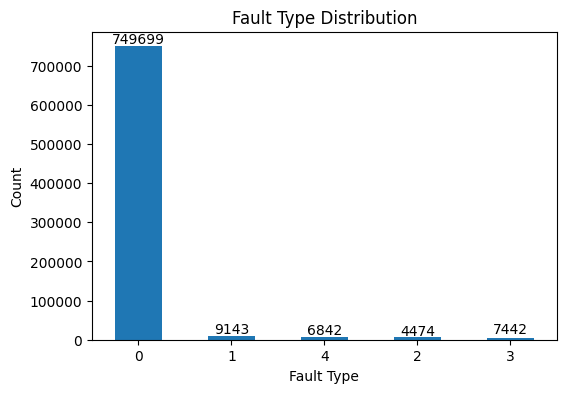

In [42]:
#Basic EDA visualizations
#fault type distribution
plt.figure(figsize=(6,4))
df['fault_type'].value_counts().plot(kind='bar')
plt.title('Fault Type Distribution')
plt.xlabel('Fault Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
#value count for each fault type
for index, value in df['fault_type'].value_counts().items():
    plt.text(index, value, str(value), ha='center', va='bottom')   
plt.show()


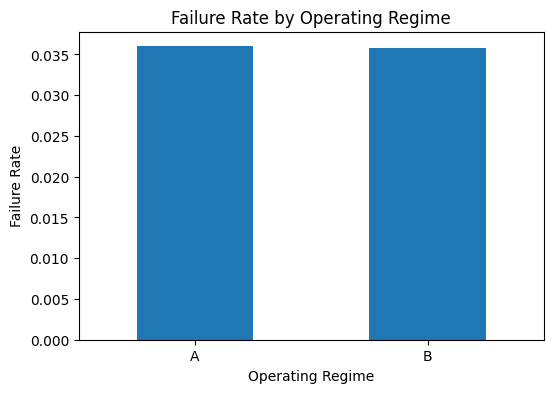

FAILURE RATE BY OPERATING REGIME:
operating_regime
A     3.6%
B    3.58%
Name: failure_risk, dtype: object


In [ ]:
#failure rate by operating regime
plt.figure(figsize=(6,4))
failure_rate = df.groupby('operating_regime')['failure_risk'].mean()
failure_rate.plot(kind='bar')
plt.title('Failure Rate by Operating Regime')
plt.xlabel('Operating Regime')
plt.ylabel('Failure Rate')
plt.xticks(rotation=0)
plt.show()
#print failure rate in percentage   
print(f"FAILURE RATE BY OPERATING REGIME:\n{(failure_rate * 100).round(2).astype(str) + '%'}")

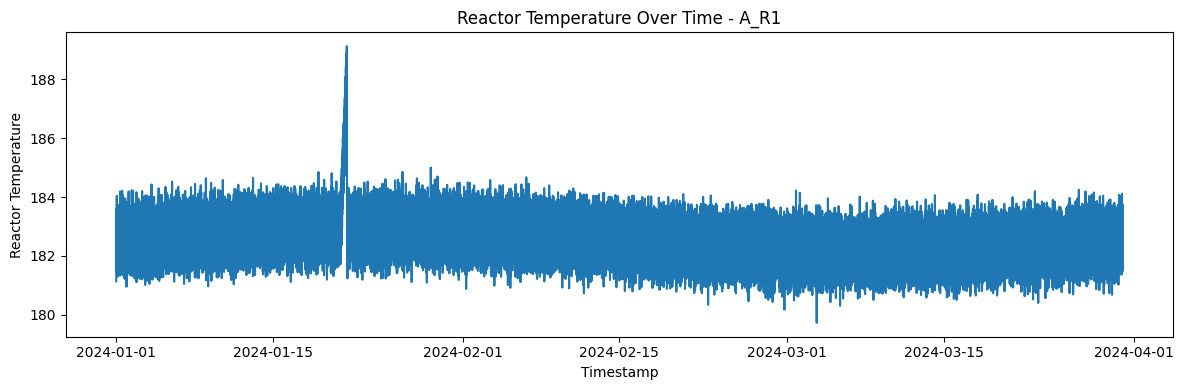

In [44]:
sample_reactor = df["reactor_id"].iloc[0]
sample_df = df[df["reactor_id"] == sample_reactor]

plt.figure(figsize=(12, 4))
plt.plot(sample_df["timestamp"], sample_df["reactor_temp"])
plt.title(f"Reactor Temperature Over Time - {sample_reactor}")
plt.xlabel("Timestamp")
plt.ylabel("Reactor Temperature")
plt.tight_layout()
plt.show()

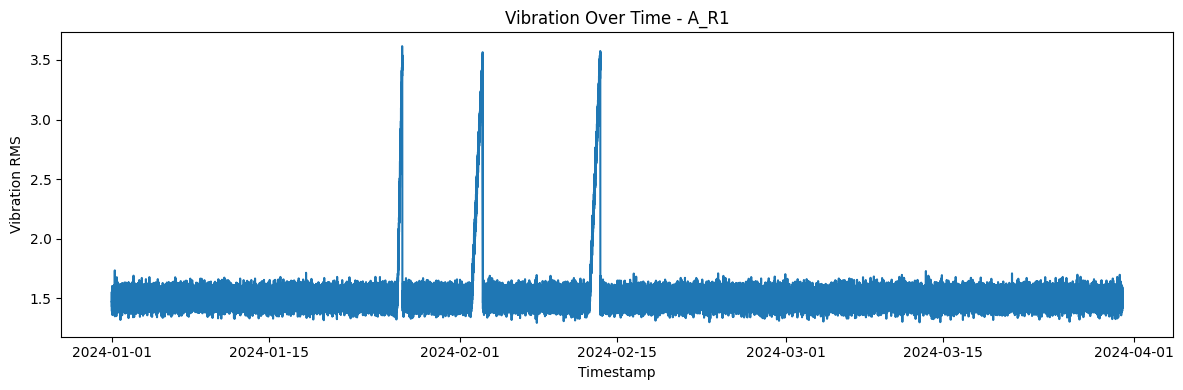

In [45]:
plt.figure(figsize=(12, 4))
plt.plot(sample_df["timestamp"], sample_df["vibration_rms"])
plt.title(f"Vibration Over Time - {sample_reactor}")
plt.xlabel("Timestamp")
plt.ylabel("Vibration RMS")
plt.tight_layout()
plt.show()

In [46]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
#what is the timestamp data type and range
print(f"TIMESTAMP DATA TYPE: {df['timestamp'].dtype}")
print(f"TIMESTAMP RANGE: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()


TIMESTAMP DATA TYPE: datetime64[ns]
TIMESTAMP RANGE: 2024-01-01 00:00:00 to 2024-03-30 23:59:00


,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min,failure_risk
0,2024-01-01 00:00:00,A,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,0.724542,...,82.032893,1.470297,45.882315,41.294083,180.0,12.0,0,0.0,878.0,0
1,2024-01-01 00:01:00,A,A_R1,0.000485,182.249820,15.706975,98.932369,79.874191,302.283603,0.728999,...,81.301503,1.425847,46.755905,42.080314,180.0,12.0,0,0.0,878.0,0
2,2024-01-01 00:02:00,A,A_R1,0.000970,183.129737,15.593397,99.792219,80.593736,305.814440,0.732519,...,82.006626,1.448190,46.309038,41.678134,180.0,12.0,0,0.0,878.0,0
3,2024-01-01 00:03:00,A,A_R1,0.001454,183.020987,15.527333,99.854222,80.190444,304.436123,0.732084,...,81.562261,1.473448,45.862171,41.275954,180.0,12.0,0,0.0,878.0,0
4,2024-01-01 00:04:00,A,A_R1,0.001939,183.077096,15.554044,99.302349,78.571707,304.811418,0.732308,...,82.411124,1.523491,46.880227,42.192204,180.0,12.0,0,0.0,878.0,0


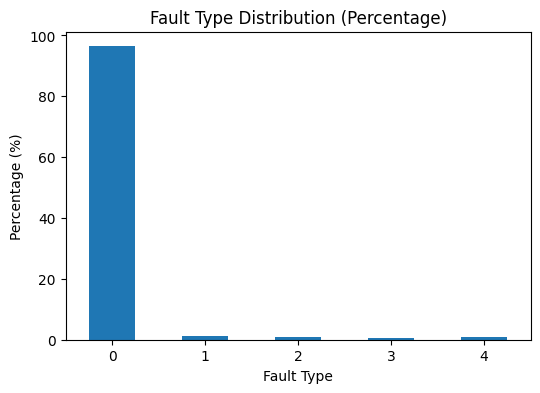

In [47]:
failure_count = df["fault_type"].value_counts().sort_index()
failure_precent = df["fault_type"].value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "count": failure_count,
    "percent": failure_precent
})

class_balance
#ploting class balance
plt.figure(figsize=(6,4))   
class_balance["percent"].plot(kind='bar')
plt.title('Fault Type Distribution (Percentage)')
plt.xlabel('Fault Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()


Fault class 0 represents normal operation. Fault classes 1–4 are less frequent, which means the dataset is imbalanced. For this reason, accuracy alone will not be enough during model evaluation. Precision, recall, and F1-score will be more important.

In [48]:
regime_summary = df.groupby("operating_regime").agg(
    rows=("fault_type", "count"),
    failure_rate=("failure_risk", "mean"),
    avg_efficiency_loss=("efficiency_loss_pct", "mean"),
    avg_reactor_temp=("reactor_temp", "mean"),
    avg_pressure=("reactor_pressure", "mean"),
    avg_vibration=("vibration_rms", "mean")
)

regime_summary

,rows,failure_rate,avg_efficiency_loss,avg_reactor_temp,avg_pressure,avg_vibration
operating_regime,,,,,,
A,388800,0.035993,0.539918,181.300454,15.678904,1.512570
B,388800,0.035769,0.536574,194.631813,17.564420,1.506479


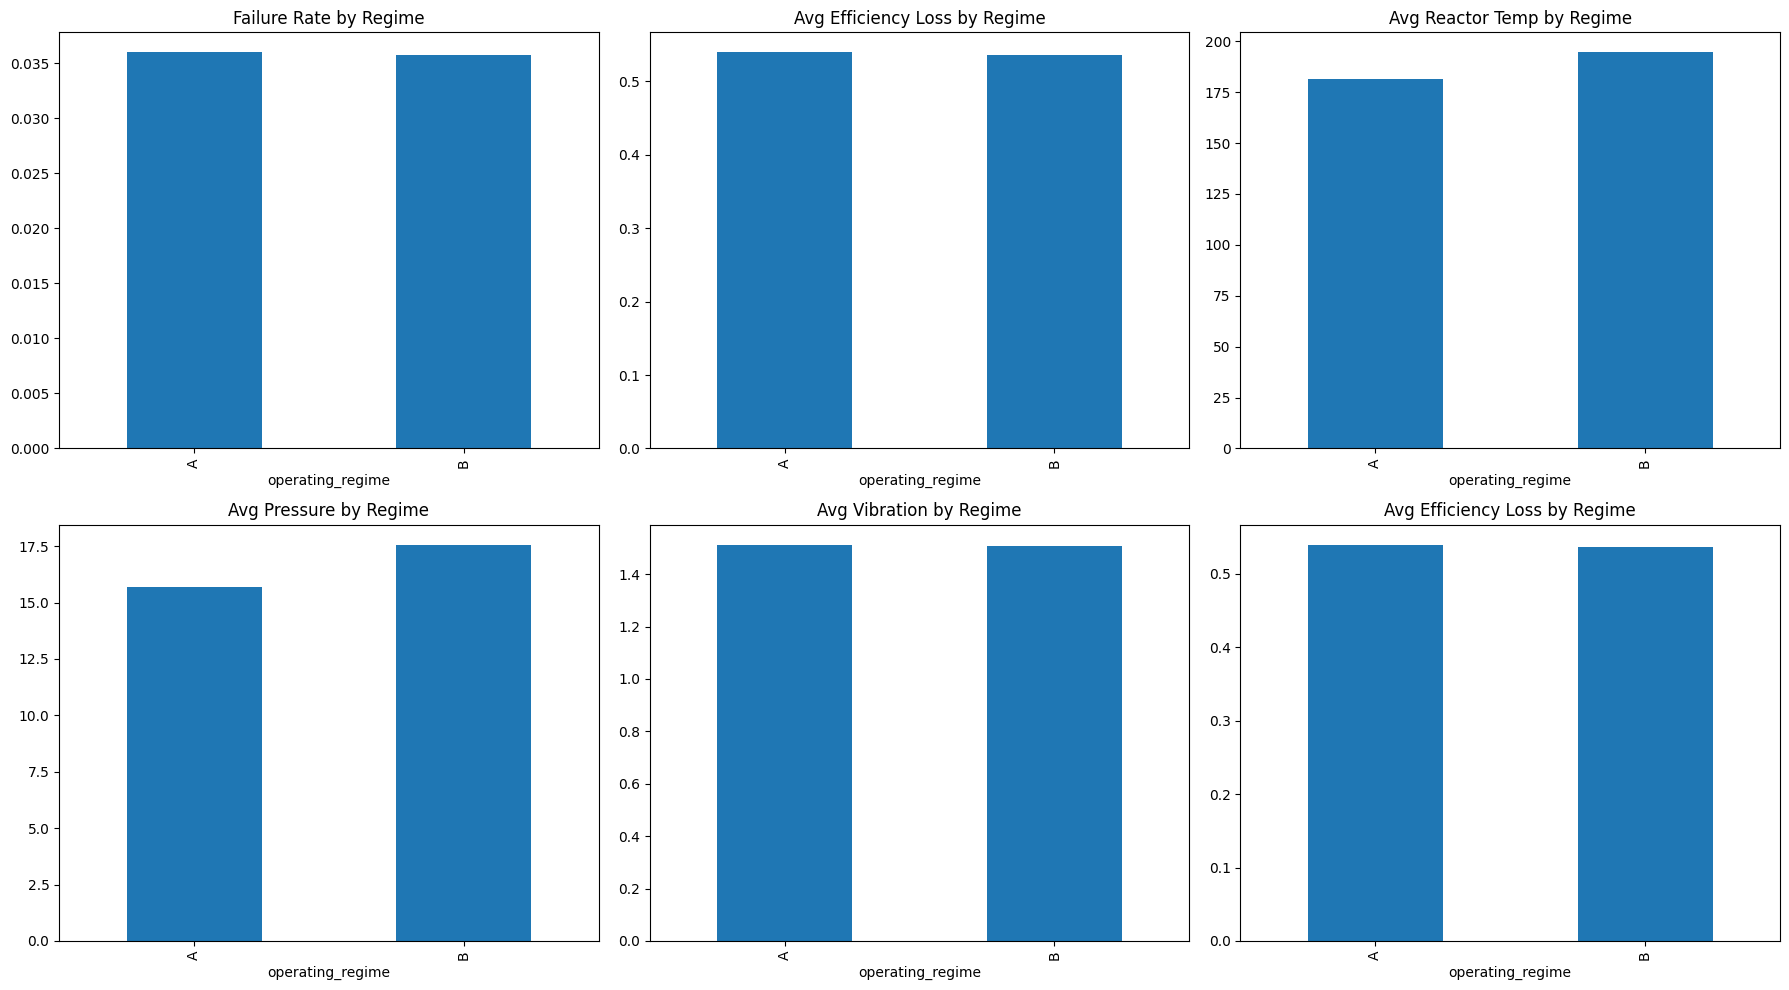

In [49]:
#plot regime summary
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
regime_summary["failure_rate"].plot(kind='bar', ax=axes[0, 0], title="Failure Rate by Regime")
regime_summary["avg_efficiency_loss"].plot(kind='bar', ax=axes[0, 1], title="Avg Efficiency Loss by Regime")
regime_summary["avg_reactor_temp"].plot(kind='bar', ax=axes[0, 2], title="Avg Reactor Temp by Regime")
regime_summary["avg_pressure"].plot(kind='bar', ax=axes[1, 0], title="Avg Pressure by Regime")
regime_summary["avg_vibration"].plot(kind='bar', ax=axes[1, 1], title="Avg Vibration by Regime")
regime_summary["avg_efficiency_loss"].plot(kind='bar', ax=axes[1, 2], title="Avg Efficiency Loss by Regime")
plt.tight_layout()
plt.show()


Regime B shows higher average reactor temperature and pressure than Regime A, confirming that it represents a more stressful operating regime.
Although Regime B operates under higher temperature and pressure, the average failure rate is similar across both regimes. This suggests that operating regime alone may not be sufficient to explain failure occurrence. Sensor-level patterns and reactor-specific behavior should be analyzed further.
Average efficiency loss is also very similar between regimes, indicating that failure and performance degradation may depend more on local sensor behavior, reactor identity, and time-dependent fault development than on operating regime alone.

In [50]:
sensor_cols = [
    "reactor_temp",
    "reactor_pressure",
    "feed_flow_rate",
    "coolant_flow_rate",
    "agitator_speed_rpm",
    "reaction_rate",
    "conversion_rate",
    "selectivity",
    "yield_pct",
    "vibration_rms",
    "motor_current",
    "power_consumption_kw"
]

normal_faulty_summary = df.groupby("failure_risk")[sensor_cols].mean().T
normal_faulty_summary.columns = ["normal", "faulty"]

normal_faulty_summary["difference"] = (
    normal_faulty_summary["faulty"] - normal_faulty_summary["normal"]
)

normal_faulty_summary["relative_difference_pct"] = (
    normal_faulty_summary["difference"] / normal_faulty_summary["normal"] * 100
)

normal_faulty_summary.sort_values(
    "relative_difference_pct",
    key=abs,
    ascending=False
)



,normal,faulty,difference,relative_difference_pct
vibration_rms,1.499953,1.766703,0.266750,17.783872
coolant_flow_rate,76.020839,73.838311,-2.182528,-2.870960
feed_flow_rate,104.002130,101.544667,-2.457463,-2.362897
motor_current,46.000188,46.668199,0.668011,1.452191
conversion_rate,99.395854,98.185222,-1.210632,-1.217991
reactor_temp,187.917761,189.265905,1.348145,0.717412
reaction_rate,0.751673,0.752822,0.001150,0.152944
reactor_pressure,16.621808,16.617750,-0.004058,-0.024415
yield_pct,82.002398,82.015426,0.013027,0.015887
agitator_speed_rpm,299.993603,299.995512,0.001909,0.000636


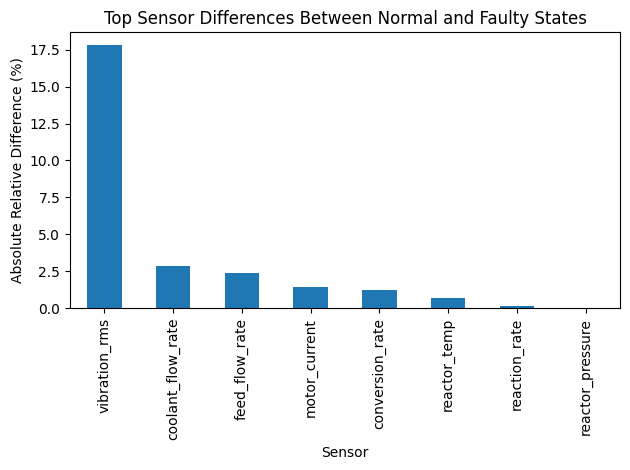

In [51]:
top_diff = (
    normal_faulty_summary["relative_difference_pct"]
    .abs()
    .sort_values(ascending=False)
    .head(8)
)

top_diff.plot(kind="bar")
plt.title("Top Sensor Differences Between Normal and Faulty States")
plt.xlabel("Sensor")
plt.ylabel("Absolute Relative Difference (%)")
plt.tight_layout()
plt.show()

Regime B shows higher average reactor temperature and pressure, confirming that it represents a more stressful operating condition. However, the failure rate and average efficiency loss are very similar between Regime A and Regime B. Therefore, operating regime alone does not explain failure occurrence. The next analysis focuses on reactor-level behavior and differences between normal and faulty sensor patterns.

              rows  failure_rate  avg_efficiency_loss  avg_time_to_fault  \
reactor_id                                                                 
A_R1        129600      0.048750             0.731250         284.677284   
A_R2        129600      0.023133             0.346991         847.310301   
A_R3        129600      0.036096             0.541512         437.816493   
B_R1        129600      0.044815             0.672222         227.107585   
B_R2        129600      0.018920             0.283796         309.655864   
B_R3        129600      0.043573             0.653704         357.328272   

            avg_vibration    avg_temp  
reactor_id                             
A_R1             1.526025  182.560465  
A_R2             1.504780  181.026734  
A_R3             1.506905  180.314163  
B_R1             1.505652  194.376789  
B_R2             1.505280  193.706839  
B_R3             1.508505  195.811811  


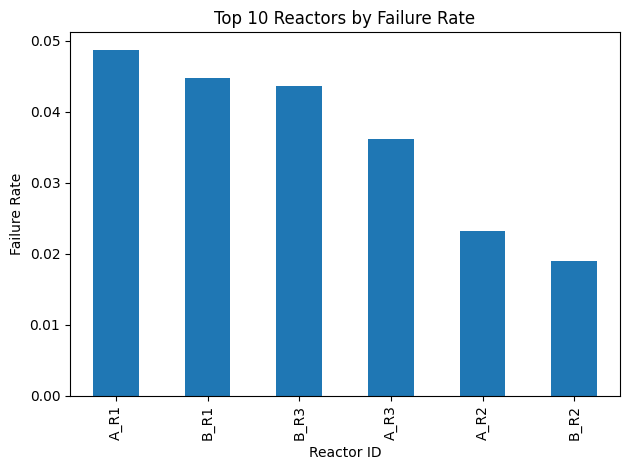

In [52]:
reactor_summary = df.groupby("reactor_id").agg(
    rows=("fault_type", "count"),
    failure_rate=("failure_risk", "mean"),
    avg_efficiency_loss=("efficiency_loss_pct", "mean"),
    avg_time_to_fault=("time_to_fault_min", "mean"),
    avg_vibration=("vibration_rms", "mean"),
    avg_temp=("reactor_temp", "mean")
).sort_values("failure_rate", ascending=False)

print(reactor_summary.sort_index())
print("=" * 50)
reactor_summary["failure_rate"].head(10).plot(kind="bar")
plt.title("Top 10 Reactors by Failure Rate")
plt.xlabel("Reactor ID")
plt.ylabel("Failure Rate")
plt.tight_layout()
plt.show()

The regime-level analysis showed similar average failure rates across Regime A and Regime B. However, the reactor-level analysis reveals stronger differences between individual reactors. For example, A_R1, B_R1, and B_R3 show substantially higher failure rates and efficiency losses than A_R2 and B_R2. This suggests that reactor-specific behavior is more informative than operating regime alone for maintenance prioritization.

In [53]:
#craeting time features
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

rolling_cols = [
    "reactor_temp",
    "reactor_pressure",
    "coolant_flow_rate",
    "vibration_rms",
    "motor_current",
    "power_consumption_kw"
]

for col in rolling_cols:
    df[f"{col}_rolling_mean_60"] = (
        df.groupby("reactor_id")[col]
          .transform(lambda x: x.rolling(window=60, min_periods=10).mean())
    )
    
    df[f"{col}_rolling_std_60"] = (
        df.groupby("reactor_id")[col]
          .transform(lambda x: x.rolling(window=60, min_periods=10).std())
    )

df = df.sort_values(["reactor_id", "timestamp"])

numeric_cols = df.select_dtypes(include=["number"]).columns

df[numeric_cols] = (
    df.groupby("reactor_id")[numeric_cols]
      .transform(lambda x: x.ffill().bfill())
)

In [54]:
df.to_csv("F:\_30 Day Job Project\predictive-maintenance-optimizer\data\processed\ml_ready_data.csv", index=False)


In [55]:
reactor_summary.to_csv(r"F:\_30 Day Job Project\predictive-maintenance-optimizer\outputs\results\reactor_summary.csv", index=True)